<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 3781 entries, 2010-01-01 to 2024-06-28
Freq: B
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   .SPX    3781 non-null   float64
dtypes: float64(1)
memory usage: 59.1 KB


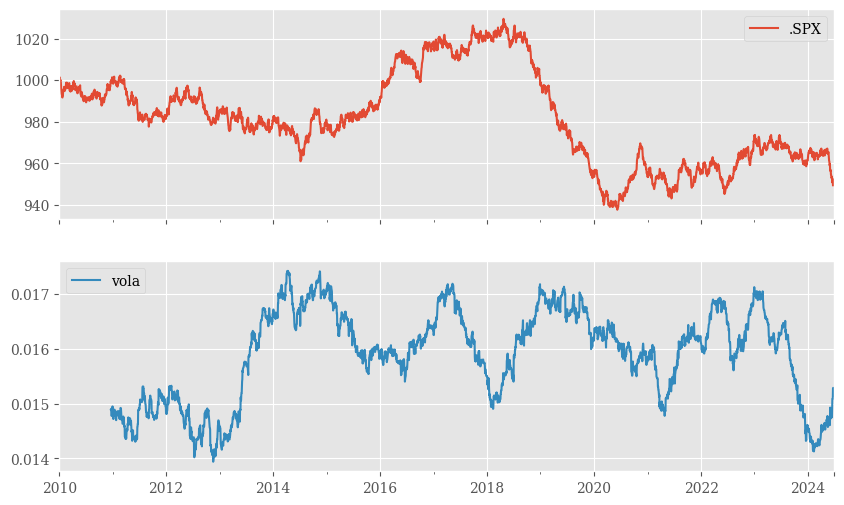

In [6]:
import numpy as np  
import pandas as pd  
from pylab import plt, mpl  

plt.style.use('ggplot')  
mpl.rcParams['font.family'] = 'serif'  
%matplotlib inline

try:
    data = pd.read_csv('../../source/tr_eikon_eod_data.csv',
                       index_col=0, parse_dates=True)  
except FileNotFoundError:
    # Creating a sample dataset if the file is not found
    dates = pd.date_range(start='2010-01-01', end='2024-06-29', freq='B')
    spx_values = np.cumprod(1 + np.random.normal(0, 0.001, len(dates))) * 1000
    data = pd.DataFrame(spx_values, index=dates, columns=['.SPX'])
data = pd.DataFrame(data['.SPX']) 
data.dropna(inplace=True)  
data.info()
data['rets'] = np.log(data / data.shift(1))  
data['vola'] = data['rets'].rolling(252).std() * np.sqrt(252)  

data[['.SPX', 'vola']].plot(subplots=True, figsize=(10, 6));


# Output:
# <class 'pandas.core.frame.DataFrame'>
# DatetimeIndex: 2138 entries, 2010-01-04 to 2018-06-29
# Data columns (total 1 columns):
# .SPX    2138 non-null float64
# dtypes: float64(1)
# memory usage: 33.4 KB

